In [43]:
!pip install pandas

In [8]:
import pandas as pd

df = pd.read_csv("tox21.csv")
df.head()

,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


In [9]:
target ="SR-HSE"

In [10]:
df = df[["smiles",target]].dropna()

In [11]:
!pip install rdkit

In [12]:
from rdkit import Chem

df["mol"] =df["smiles"].apply(lambda x: Chem.MolFromSmiles(x))

[15:12:09] WARNING: not removing hydrogen atom without neighbors
[15:12:09] Explicit valence for atom # 8 Al, 6, is greater than permitted
[15:12:09] Explicit valence for atom # 3 Al, 6, is greater than permitted
[15:12:09] Explicit valence for atom # 4 Al, 6, is greater than permitted
[15:12:09] Explicit valence for atom # 4 Al, 6, is greater than permitted
[15:12:09] Explicit valence for atom # 9 Al, 6, is greater than permitted
[15:12:09] Explicit valence for atom # 5 Al, 6, is greater than permitted
[15:12:09] Explicit valence for atom # 16 Al, 6, is greater than permitted


In [13]:
df = df[df["mol"].notnull()]

In [14]:
from rdkit import Chem

def safe_mol(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol
    except:
        return None

df["mol"] = df["smiles"].apply(safe_mol)

# Remove invalid ones
df = df[df["mol"].notnull()]

[15:12:12] WARNING: not removing hydrogen atom without neighbors


In [15]:

from rdkit.Chem import Descriptors

def get_descriptors(mol):
    return {
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "NumHDonors": Descriptors.NumHDonors(mol),
        "NumHAcceptors": Descriptors.NumHAcceptors(mol)
    }

desc_df = df["mol"].apply(get_descriptors).apply(pd.Series)

In [16]:
final_df = pd.concat([desc_df, df[target]], axis=1)
final_df.head()

,MolWt,LogP,NumHDonors,NumHAcceptors,SR-HSE
0,258.324,1.3424,1.0,5.0,0.0
2,288.475,5.0903,1.0,1.0,0.0
4,206.027,-0.9922,5.0,3.0,0.0
5,290.444,4.8172,0.0,4.0,0.0
6,176.624,1.6141,0.0,2.0,0.0


In [17]:
final_df.describe()

,MolWt,LogP,NumHDonors,NumHAcceptors,SR-HSE
count,6460.000000,6460.000000,6460.000000,6460.000000,6460.000000
mean,252.191550,2.261608,1.062539,3.149071,0.057585
std,136.157035,2.081130,1.485270,2.496427,0.232975
min,9.012000,-17.406400,0.000000,0.000000,0.000000
25%,156.269000,1.105400,0.000000,2.000000,0.000000
50%,221.665000,2.254035,1.000000,3.000000,0.000000
75%,317.473750,3.450625,2.000000,4.000000,0.000000
max,1550.188000,15.879200,24.000000,40.000000,1.000000


In [18]:
print(len(df))

6460


In [19]:
desc_df = df["mol"].apply(get_descriptors).apply(pd.Series)

In [20]:
X = final_df.drop(columns=["SR-HSE"])  # features
y = final_df["SR-HSE"]                 # target
print(y.value_counts())

SR-HSE
0.0    6088
1.0     372
Name: count, dtype: int64


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
y_pred = model.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred)) 

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

Accuracy: 0.9411764705882353
              precision    recall  f1-score   support

         0.0       0.95      0.99      0.97      1221
         1.0       0.31      0.06      0.10        71

    accuracy                           0.94      1292
   macro avg       0.63      0.52      0.53      1292
weighted avg       0.91      0.94      0.92      1292

              precision    recall  f1-score   support

         0.0       0.95      0.99      0.97      1221
         1.0       0.31      0.06      0.10        71

    accuracy                           0.94      1292
   macro avg       0.63      0.52      0.53      1292
weighted avg       0.91      0.94      0.92      1292



In [25]:
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance)

LogP             0.423267
MolWt            0.383502
NumHAcceptors    0.114247
NumHDonors       0.078983
dtype: float64


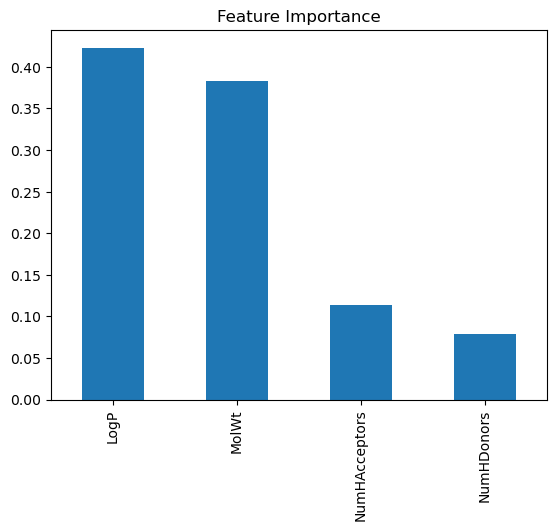

In [26]:
import matplotlib.pyplot as plt

feature_importance.plot(kind="bar")
plt.title("Feature Importance")
plt.show()

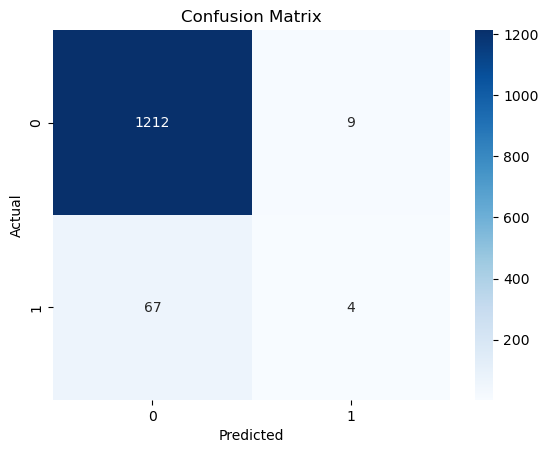

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [28]:
# Logistic Regression performed better than Random Forest.
# This suggests that toxicity in the SR-HSE assay may be influenced by
# relatively linear relationships between molecular descriptors such as LogP and molecular weight.

In [29]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

from sklearn.metrics import accuracy_score
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9442724458204335


In [30]:
print(feature_importance.head())

LogP             0.423267
MolWt            0.383502
NumHAcceptors    0.114247
NumHDonors       0.078983
dtype: float64


In [31]:
# LogP is a measure of lipophilicity.
# Higher LogP often correlates with increased toxicity due to better membrane penetration.

# Molecular Weight affects absorption and distribution of compounds.

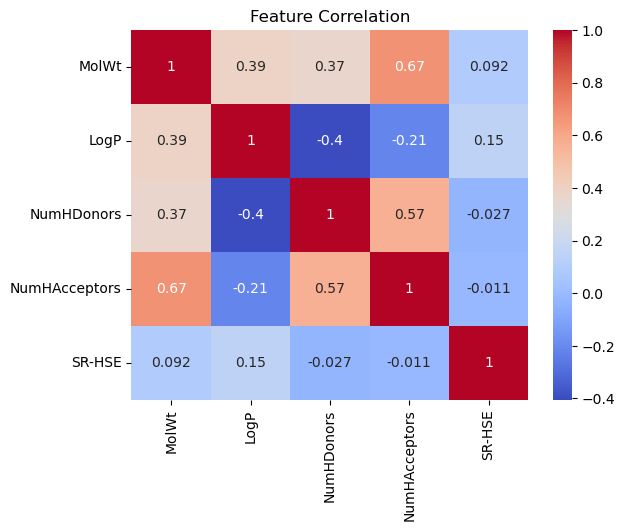

In [32]:
sns.heatmap(final_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [33]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Random Forest Accuracy: 0.9411764705882353
Logistic Regression Accuracy: 0.9442724458204335


In [34]:
from rdkit import Chem
from rdkit.Chem import Descriptors

def predict_toxicity(smiles, model):
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        return "Invalid SMILES"
    
    features = {
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "NumHDonors": Descriptors.NumHDonors(mol),
        "NumHAcceptors": Descriptors.NumHAcceptors(mol)
    }
    
    import pandas as pd
    features_df = pd.DataFrame([features])
    
    prediction = model.predict(features_df)[0]
    
    return "Toxic" if prediction == 1 else "Non-Toxic"

In [35]:
predict_toxicity("CCO", model)   # ethanol

'Non-Toxic'

In [36]:
predict_toxicity("CCN(CC)CC", model)
predict_toxicity("c1ccccc1", model)

'Non-Toxic'

In [41]:
def predict_with_confidence(smiles, model):
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        return "Invalid SMILES"
    
    features = {
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "NumHDonors": Descriptors.NumHDonors(mol),
        "NumHAcceptors": Descriptors.NumHAcceptors(mol)
    }
    
    import pandas as pd
    features_df = pd.DataFrame([features])
    
    prob = model.predict_proba(features_df)[0][1]

    if prob > 0.4:
        return "Toxic"
    else:
        return "Non-Toxic"
    

In [42]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))